# OmniFall + YOLO11n-Pose 낙상 시계열 학습 (Google Colab)

**OmniFall OF-Synthetic 영상**에서 `YOLO11n-Pose`로 사람의 17개 관절을 추출하고, 16프레임 관절 시계열을 경량 BiLSTM에 입력해 `NORMAL`, `FALLING`, `FALLEN`을 학습합니다. 학습과 실제 ROS 추론에서 동일한 Pose 특징을 사용합니다.

OmniFall 데이터와 주석은 **비상업 목적(CC BY-NC 계열)** 입니다. 상업 배포 전에는 원본 데이터별 라이선스를 다시 확인하세요. Colab 메뉴에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택한 뒤 순서대로 실행하세요.

In [ ]:
# 1. GPU와 런타임 확인
import sys, torch
print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError('런타임 유형을 T4 GPU로 변경하세요.')
print('GPU:', torch.cuda.get_device_name(0))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# 2. 패키지 설치 (OmniFall 영상 약 9.1GB가 추가로 내려받아집니다)
%pip install -q -U ultralytics datasets huggingface_hub scikit-learn opencv-python-headless av

## 데이터 선택

이 노트북은 바로 내려받을 수 있고 장면 다양성이 큰 `of-syn`을 학습에 사용합니다. `of-itw`는 실제 사고 영상이지만 평가용으로 유지하는 것이 좋고, 원본 OOPS 준비에 약 45GB 스트리밍이 필요합니다.

In [ ]:
# 3. Hugging Face에서 OF-Synthetic 주석과 영상 다운로드
# 공식 README의 pip 패키지는 아직 PyPI 배포가 지연될 수 있어 Hub 파일을 직접 사용합니다.
from pathlib import Path
from datasets import load_dataset, DatasetDict
from huggingface_hub import hf_hub_download
import tarfile

WORKDIR = Path('/content/omnifall_training')
RUNS_DIR = WORKDIR / 'runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)

dataset = load_dataset('simplexsigil2/omnifall', 'of-syn')
archive = hf_hub_download(
    repo_id='simplexsigil2/omnifall',
    repo_type='dataset',
    filename='data_files/omnifall-synthetic_av1.tar',
)
video_root = WORKDIR / 'videos'
marker = video_root / '.extracted'
if not marker.exists():
    video_root.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive) as tar:
        # 절대경로와 ../ 경로가 들어간 비정상 archive는 추출하지 않습니다.
        for member in tar.getmembers():
            target = (video_root / member.name).resolve()
            if video_root.resolve() not in target.parents and target != video_root.resolve():
                raise RuntimeError(f'안전하지 않은 archive 경로: {member.name}')
        tar.extractall(video_root, filter='data')
    marker.touch()
video_files = [p for p in video_root.rglob('*') if p.suffix.lower() in {'.mp4', '.mkv', '.webm', '.avi'}]
by_name = {p.name: str(p) for p in video_files}
by_stem = {p.stem: str(p) for p in video_files}
def attach_video_path(split):
    resolved = []
    for relative in split['path']:
        direct = video_root / str(relative)
        key = Path(str(relative))
        path = str(direct) if direct.is_file() else by_name.get(key.name) or by_stem.get(key.stem)
        if path is None:
            raise FileNotFoundError(f'주석에 대응하는 영상 없음: {relative}')
        resolved.append(path)
    return split.add_column('video', resolved)
dataset = DatasetDict({name: attach_video_path(split) for name, split in dataset.items()})
print(dataset)
print(dataset['train'].features)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['path', 'label', 'start', 'end', 'subject', 'cam', 'dataset', 'age_group', 'gender_presentation', 'monk_skin_tone', 'race_ethnicity_omb', 'bmi_band', 'height_band', 'environment_category', 'camera_shot', 'speed', 'camera_elevation', 'camera_azimuth', 'camera_distance', 'video'],
        num_rows: 15344
    })
    validation: Dataset({
        features: ['path', 'label', 'start', 'end', 'subject', 'cam', 'dataset', 'age_group', 'gender_presentation', 'monk_skin_tone', 'race_ethnicity_omb', 'bmi_band', 'height_band', 'environment_category', 'camera_shot', 'speed', 'camera_elevation', 'camera_azimuth', 'camera_distance', 'video'],
        num_rows: 1956
    })
    test: Dataset({
        features: ['path', 'label', 'start', 'end', 'subject', 'cam', 'dataset', 'age_group', 'gender_presentation', 'monk_skin_tone', 'race_ethnicity_omb', 'bmi_band', 'height_band', 'environment_category', 'camera_shot', 'speed', 'camera_elevation', 'camera_

In [ ]:
# 4. 원래 16개 행동 라벨을 응급상황 중심 3개 클래스로 변환
# OmniFall: 1=fall(넘어지는 중), 2=fallen(쓰러져 머무름), 나머지=normal
from collections import Counter

CLASS_NAMES = ['NORMAL', 'FALLING', 'FALLEN']
def target_label(original_label):
    original_label = int(original_label)
    return 1 if original_label == 1 else (2 if original_label == 2 else 0)

for split in dataset:
    counts = Counter(target_label(x) for x in dataset[split]['label'])
    print(split, {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

train {'NORMAL': 12470, 'FALLING': 1731, 'FALLEN': 1143}
validation {'NORMAL': 1595, 'FALLING': 205, 'FALLEN': 156}
test {'NORMAL': 1566, 'FALLING': 212, 'FALLEN': 150}


In [ ]:
# 5. 16프레임을 읽고 YOLO11n-Pose 관절 시계열로 변환
import cv2
import av
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, TensorDataset
from ultralytics import YOLO

NUM_FRAMES = 16
POSE_FEATURES = 17 * 3 + 5  # 정규화 xy/conf + bbox 중심/크기/aspect ratio
pose_model = YOLO('yolo11n-pose.pt')

def read_clip(path, start, end, num_frames=NUM_FRAMES):
    # OF-Synthetic는 AV1 영상이므로 OpenCV 대신 PyAV/FFmpeg로 디코딩합니다.
    # 디코딩 실패를 검은 프레임으로 숨기지 않고 즉시 오류로 처리합니다.
    try:
        with av.open(str(path)) as container:
            stream = container.streams.video[0]
            fps = float(stream.average_rate) if stream.average_rate else 16.0
            decoded = [frame.to_ndarray(format='bgr24') for frame in container.decode(video=0)]
    except Exception as exc:
        raise RuntimeError(f'AV1 영상 디코딩 실패: {path}') from exc
    if not decoded:
        raise RuntimeError(f'디코딩된 프레임이 없습니다: {path}')
    total = len(decoded)
    first = max(0, min(total - 1, int(max(0.0, float(start)) * fps)))
    last = max(first, min(total - 1, int(max(float(start), float(end)) * fps) - 1))
    indices = np.linspace(first, last, num_frames).round().astype(int)
    frames = [decoded[int(index)] for index in indices]
    if max(float(frame.mean()) for frame in frames) < 1.0:
        raise RuntimeError(f'영상이 검은 프레임으로만 디코딩됐습니다: {path}')
    return frames  # Ultralytics numpy 입력에 맞춘 BGR 프레임

def pose_sequence(frames):
    # 여러 사람이 있으면 bbox 면적이 가장 큰 사람을 주 대상으로 선택합니다.
    results = pose_model.predict(frames, imgsz=640, conf=0.25, device=0, verbose=False)
    sequence = []
    last = np.zeros(POSE_FEATURES, dtype=np.float32)
    for frame, result in zip(frames, results):
        h, w = frame.shape[:2]
        if result.boxes is None or len(result.boxes) == 0 or result.keypoints is None:
            sequence.append(last.copy()); continue
        boxes = result.boxes.xyxy.detach().cpu().numpy()
        index = int(np.argmax((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])))
        box = boxes[index]
        xy = result.keypoints.xy[index].detach().cpu().numpy()
        conf = result.keypoints.conf[index].detach().cpu().numpy()
        x1, y1, x2, y2 = box; bw, bh = max(x2-x1, 1.0), max(y2-y1, 1.0)
        # bbox 기준 정규화로 카메라 거리와 해상도 영향을 줄입니다.
        normalized_xy = np.column_stack(((xy[:, 0]-x1)/bw, (xy[:, 1]-y1)/bh))
        bbox_features = np.array([((x1+x2)/2)/w, ((y1+y2)/2)/h, bw/w, bh/h, bw/bh], np.float32)
        last = np.concatenate([normalized_xy.reshape(-1), conf, bbox_features]).astype(np.float32)
        sequence.append(last.copy())
    return torch.from_numpy(np.stack(sequence))  # T,F

class OmniFallClips(Dataset):
    def __init__(self, split, training=False):
        self.rows = split
        self.training = training
        self.targets = [target_label(x) for x in split['label']]
    def __len__(self): return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        path = row.get('video') or row.get('path')
        frames = read_clip(path, row['start'], row['end'])
        return pose_sequence(frames), self.targets[index]

preflight NORMAL: shape=(720, 1280, 3), mean=102.3, pose_detected=100.0%
preflight FALLING: shape=(720, 1280, 3), mean=107.1, pose_detected=100.0%
preflight FALLEN: shape=(720, 1280, 3), mean=134.2, pose_detected=100.0%


YOLO11n-Pose train:   0%|          | 0/15344 [00:00<?, ?it/s]

YOLO11n-Pose validation:   0%|          | 0/1956 [00:00<?, ?it/s]

YOLO11n-Pose test:   0%|          | 0/1928 [00:00<?, ?it/s]


[train] sequences=15,344, detected_frames=99.9%, empty_sequences=0.0%
  NORMAL : count=12470, detected_frames=99.9%, empty=0.0%, mean_kpt_conf=0.824
  FALLING: count= 1731, detected_frames=99.6%, empty=0.0%, mean_kpt_conf=0.784
  FALLEN : count= 1143, detected_frames=100.0%, empty=0.0%, mean_kpt_conf=0.794

[validation] sequences=1,956, detected_frames=99.8%, empty_sequences=0.2%
  NORMAL : count= 1595, detected_frames=99.8%, empty=0.2%, mean_kpt_conf=0.821
  FALLING: count=  205, detected_frames=99.6%, empty=0.0%, mean_kpt_conf=0.778
  FALLEN : count=  156, detected_frames=100.0%, empty=0.0%, mean_kpt_conf=0.781

[test] sequences=1,928, detected_frames=99.9%, empty_sequences=0.1%
  NORMAL : count= 1566, detected_frames=100.0%, empty=0.0%, mean_kpt_conf=0.817
  FALLING: count=  212, detected_frames=99.7%, empty=0.0%, mean_kpt_conf=0.785
  FALLEN : count=  150, detected_frames=99.3%, empty=0.7%, mean_kpt_conf=0.796
feature shapes: torch.Size([15344, 16, 56]) torch.Size([1956, 16, 56]) 

/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 46988 (\N{HANGUL SYLLABLE RAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3222/86990698.py:73: UserWarning: Glyph 50640 (\N{HANGUL SYLLAB

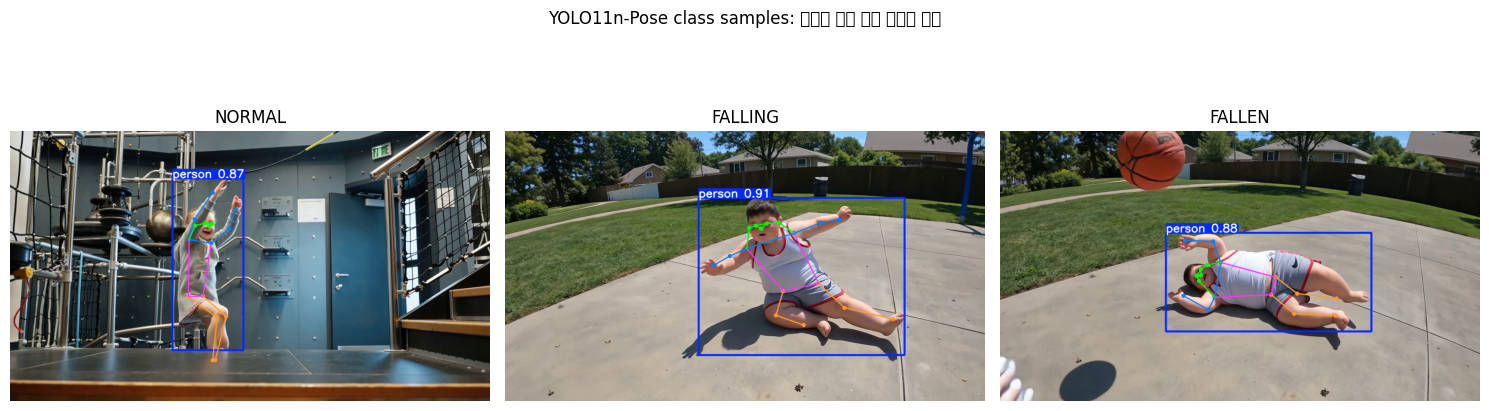

In [ ]:
# 6. Pose 특징을 한 번만 추출해 캐시한 뒤 DataLoader 구성
# 첫 실행은 오래 걸리지만 이후 학습 epoch에서는 YOLO를 다시 실행하지 않습니다.
from tqdm.auto import tqdm
BATCH_SIZE = 128
# OpenCV로 잘못 생성된 이전 캐시와 분리합니다.
FEATURE_CACHE = WORKDIR / 'pose_features_yolo11n_16f_pyav_v2.pt'

# 전체 특징 추출 전에 실제 영상과 Pose가 정상인지 즉시 확인합니다.
for class_id, class_name in enumerate(CLASS_NAMES):
    targets = [target_label(x) for x in dataset['train']['label']]
    sample_index = targets.index(class_id)
    row = dataset['train'][sample_index]
    sample_frames = read_clip(row['video'], row['start'], row['end'])
    sample_pose = pose_sequence(sample_frames)
    detected = (sample_pose[:, 34:51].amax(dim=1) > 0).float().mean().item()
    print(f'preflight {class_name}: shape={sample_frames[0].shape}, mean={sample_frames[0].mean():.1f}, pose_detected={detected:.1%}')
    if detected == 0:
        raise RuntimeError(f'{class_name} 샘플에서 Pose가 한 프레임도 검출되지 않았습니다. 전체 추출을 중단합니다.')

def extract_split(name):
    source = OmniFallClips(dataset[name], training=False)
    features, labels = [], []
    for index in tqdm(range(len(source)), desc=f'YOLO11n-Pose {name}'):
        x, y = source[index]; features.append(x); labels.append(y)
    return torch.stack(features), torch.tensor(labels, dtype=torch.long)

if FEATURE_CACHE.exists():
    cached = torch.load(FEATURE_CACHE, map_location='cpu', weights_only=True)
else:
    cached = {name: extract_split(name) for name in ('train', 'validation', 'test')}
    torch.save(cached, FEATURE_CACHE)

train_x, train_y = cached['train']; val_x, val_y = cached['validation']; test_x, test_y = cached['test']

# 학습 전에 Pose 입력 품질을 확인합니다. conf 17개는 feature 34:51에 있습니다.
def pose_quality(name, x, y):
    frame_detected = x[:, :, 34:51].amax(dim=2) > 0
    print(f'\n[{name}] sequences={len(y):,}, detected_frames={frame_detected.float().mean():.1%}, empty_sequences={(~frame_detected.any(dim=1)).float().mean():.1%}')
    for class_id, class_name in enumerate(CLASS_NAMES):
        mask = y == class_id
        rate = frame_detected[mask].float().mean().item() if mask.any() else 0.0
        empty = (~frame_detected[mask].any(dim=1)).float().mean().item() if mask.any() else 0.0
        confidence = x[mask, :, 34:51][x[mask, :, 34:51] > 0].mean().item() if (x[mask, :, 34:51] > 0).any() else 0.0
        print(f'  {class_name:7s}: count={int(mask.sum()):5d}, detected_frames={rate:.1%}, empty={empty:.1%}, mean_kpt_conf={confidence:.3f}')
    return frame_detected.float().mean().item()

quality = [pose_quality('train', train_x, train_y), pose_quality('validation', val_x, val_y), pose_quality('test', test_x, test_y)]
if min(quality) < 0.5:
    print('WARNING: Pose 검출률이 50% 미만입니다. 이 상태의 F1은 신뢰하기 어렵습니다.')
train_set = TensorDataset(train_x, train_y); val_set = TensorDataset(val_x, val_y); test_set = TensorDataset(test_x, test_y)
counts = Counter(train_y.tolist())
weights = [1.0 / counts[int(y)] for y in train_y]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
# Colab/Jupyter에서 worker 프로세스의 부모 PID가 꼬이는 문제를 피합니다.
# 특징은 이미 RAM의 TensorDataset에 있으므로 num_workers=0의 성능 손실도 작습니다.
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print('feature shapes:', train_x.shape, val_x.shape, test_x.shape)

# 클래스별 실제 Pose 추출 예시를 눈으로 확인합니다.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
validation_targets = [target_label(x) for x in dataset['validation']['label']]
for class_id, axis in enumerate(axes):
    sample_index = validation_targets.index(class_id)
    row = dataset['validation'][sample_index]
    frames = read_clip(row['video'], row['start'], row['end'])
    result = pose_model.predict(frames[len(frames)//2], imgsz=640, conf=0.25, device=0, verbose=False)[0]
    axis.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    axis.set_title(CLASS_NAMES[class_id]); axis.axis('off')
plt.suptitle('YOLO11n-Pose class samples: 관절이 사람 위에 맞는지 확인')
plt.tight_layout(); plt.show()

In [ ]:
# 7. 관절 시계열용 경량 BiLSTM 구성
from torch import nn

class FallPoseLSTM(nn.Module):
    def __init__(self, input_size=POSE_FEATURES, hidden_size=128, classes=3):
        super().__init__()
        # 원본 Pose와 프레임 간 변화량을 함께 사용합니다.
        self.norm = nn.LayerNorm(input_size * 2)
        self.lstm = nn.LSTM(input_size * 2, hidden_size, num_layers=2, batch_first=True, bidirectional=True, dropout=0.25)
        self.head = nn.Sequential(nn.Linear(hidden_size * 2, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, classes))
    def forward(self, sequence):
        delta = torch.zeros_like(sequence)
        delta[:, 1:] = sequence[:, 1:] - sequence[:, :-1]
        features = self.norm(torch.cat([sequence, delta], dim=-1))
        _, (hidden, _) = self.lstm(features)
        # 마지막 layer의 정방향·역방향 최종 hidden을 결합합니다.
        summary = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.head(summary)

device = torch.device('cuda')
model = FallPoseLSTM(classes=len(CLASS_NAMES)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
scaler = torch.amp.GradScaler('cuda')
print('parameters:', sum(p.numel() for p in model.parameters()))

parameters: 676579


In [ ]:
# 8. BiLSTM 학습 및 macro-F1 기준 best.pt 저장
from sklearn.metrics import f1_score, classification_report
from tqdm.auto import tqdm

EPOCHS = 30
BEST_WEIGHTS = RUNS_DIR / 'omnifall_yolo11n_pose_lstm_best.pt'
best_f1 = -1.0

@torch.inference_mode()
def evaluate(loader):
    model.eval(); predictions, targets, losses = [], [], []
    for clips, labels in tqdm(loader, leave=False):
        clips, labels = clips.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(clips)
        losses.append(criterion(logits, labels).item())
        predictions.extend(logits.argmax(1).cpu().tolist()); targets.extend(labels.cpu().tolist())
    return float(np.mean(losses)), f1_score(targets, predictions, average='macro'), targets, predictions

for epoch in range(1, EPOCHS + 1):
    model.train(); train_losses = []
    for clips, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        clips, labels = clips.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = criterion(model(clips), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        train_losses.append(loss.item())
    val_loss, val_f1, _, _ = evaluate(val_loader)
    scheduler.step()
    print(f'epoch={epoch} train_loss={np.mean(train_losses):.4f} val_loss={val_loss:.4f} macro_f1={val_f1:.4f}')
    if epoch == 1 or epoch % 5 == 0:
        _, _, val_true, val_pred = evaluate(val_loader)
        print(classification_report(val_true, val_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({'model': model.state_dict(), 'classes': CLASS_NAMES, 'num_frames': NUM_FRAMES, 'pose_features': POSE_FEATURES, 'pose_model': 'yolo11n-pose.pt', 'val_macro_f1': best_f1}, BEST_WEIGHTS)
print('Best:', BEST_WEIGHTS, 'macro_f1=', best_f1)

Epoch 1/30:   0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

epoch=1 train_loss=0.9024 val_loss=0.6912 macro_f1=0.5888


  0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      NORMAL      0.984     0.693     0.814      1595
     FALLING      0.367     0.771     0.498       205
      FALLEN      0.316     0.814     0.455       156

    accuracy                          0.711      1956
   macro avg      0.556     0.759     0.589      1956
weighted avg      0.866     0.711     0.752      1956



...

Epoch 30/30:   0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

epoch=30 train_loss=0.3891 val_loss=0.5527 macro_f1=0.7023


  0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

      NORMAL      0.979     0.814     0.889      1595
     FALLING      0.627     0.868     0.728       205
      FALLEN      0.355     0.788     0.490       156

    accuracy                          0.817      1956
   macro avg      0.654     0.824     0.702      1956
weighted avg      0.892     0.817     0.840      1956

Best: /content/omnifall_training/runs/omnifall_yolo11n_pose_lstm_best.pt macro_f1= 0.7113613352279137


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

val_loss: 0.5170637434348464 val_macro_f1: 0.7113613352279137
              precision    recall  f1-score   support

      NORMAL     0.9748    0.8245    0.8933      1595
     FALLING     0.6870    0.8244    0.7494       205
      FALLEN     0.3518    0.8141    0.4913       156

    accuracy                         0.8236      1956
   macro avg     0.6712    0.8210    0.7114      1956
weighted avg     0.8949    0.8236    0.8462      1956

test_loss: 0.5276889726519585 test_macro_f1: 0.6957143635231869
              precision    recall  f1-score   support

      NORMAL     0.9673    0.8116    0.8826      1566
     FALLING     0.6856    0.8538    0.7605       212
      FALLEN     0.3171    0.7400    0.4440       150

    accuracy                         0.8107      1928
   macro avg     0.6567    0.8018    0.6957      1928
weighted avg     0.8857    0.8107    0.8351      1928



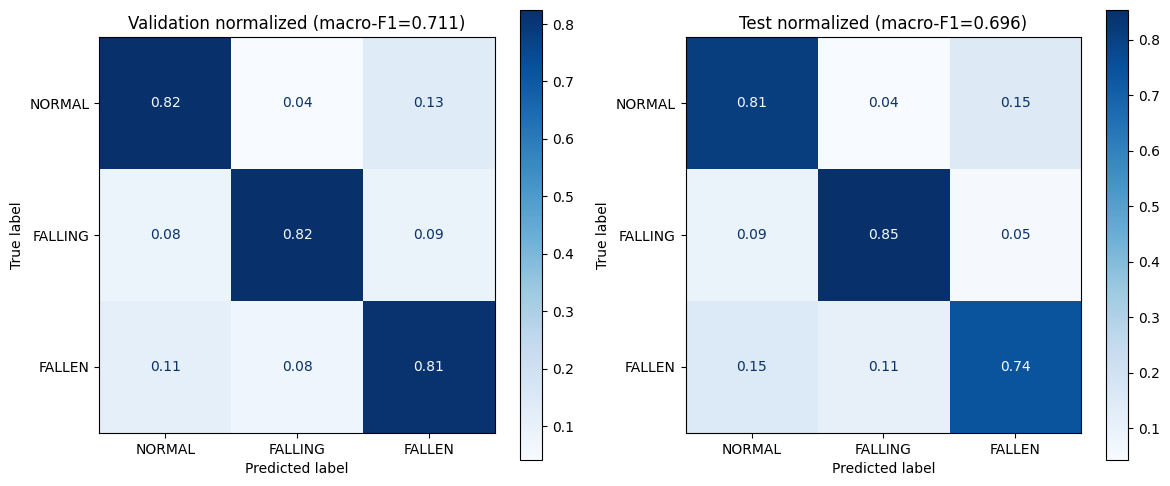

confusion matrix: /content/omnifall_training/runs/pose_lstm_confusion_matrix.png


In [ ]:
# 9. best 모델의 validation/test 평가와 confusion matrix
checkpoint = torch.load(BEST_WEIGHTS, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model'])
val_loss, val_f1, val_true, val_pred = evaluate(val_loader)
test_loss, test_f1, y_true, y_pred = evaluate(test_loader)
print('val_loss:', val_loss, 'val_macro_f1:', val_f1)
print(classification_report(val_true, val_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
print('test_loss:', test_loss, 'test_macro_f1:', test_f1)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(val_true, val_pred, display_labels=CLASS_NAMES, normalize='true', cmap='Blues', ax=axes[0], values_format='.2f')
axes[0].set_title(f'Validation normalized (macro-F1={val_f1:.3f})')
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_NAMES, normalize='true', cmap='Blues', ax=axes[1], values_format='.2f')
axes[1].set_title(f'Test normalized (macro-F1={test_f1:.3f})')
plt.tight_layout()
matrix_path = RUNS_DIR / 'pose_lstm_confusion_matrix.png'
plt.savefig(matrix_path, dpi=160, bbox_inches='tight')
plt.show()
print('confusion matrix:', matrix_path)

In [ ]:
# 10. best 모델 다운로드 및 Google Drive 백업
from google.colab import drive, files
import shutil
drive.mount('/content/drive')
destination = Path('/content/drive/MyDrive/omnifall_yolo11n_pose_lstm_best.pt')
shutil.copy2(BEST_WEIGHTS, destination)
print('Drive 저장:', destination, destination.stat().st_size, 'bytes')
files.download(str(BEST_WEIGHTS))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive 저장: /content/drive/MyDrive/omnifall_yolo11n_pose_lstm_best.pt 2711689 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>